# Zero-Shot TimesFM on Raw SSMI (Baseline)

Matches Filipp's original zero-shot setup: no filtering, a single forecast per segment on the raw 120-day window. Sliding-window config, metrics, and `freq=[0]` are identical to `TimesFM_Filtering.ipynb` so results are directly comparable to MA / HP / Butterworth / Kalman runs.

 See https://github.com/google-research/timesfm/blob/master/README.md for updated APIs.
Loaded PyTorch TimesFM, likely because python version is 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)].


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Segment 1/251 — RMSE: 68.46 | MAPE: 3.47% | R²: 0.6042 | Dir Acc: 53.3%
Segment 2/251 — RMSE: 39.64 | MAPE: 2.18% | R²: 0.6142 | Dir Acc: 46.7%
Segment 3/251 — RMSE: 32.26 | MAPE: 0.95% | R²: 0.0008 | Dir Acc: 46.7%
Segment 4/251 — RMSE: 21.14 | MAPE: 1.12% | R²: 0.1779 | Dir Acc: 63.3%
Segment 5/251 — RMSE: 64.82 | MAPE: 3.06% | R²: 0.8851 | Dir Acc: 36.7%
Segment 6/251 — RMSE: 36.93 | MAPE: 1.88% | R²: 0.7888 | Dir Acc: 63.3%
Segment 7/251 — RMSE: 88.47 | MAPE: 4.19% | R²: 0.6480 | Dir Acc: 40.0%
Segment 8/251 — RMSE: 41.99 | MAPE: 1.88% | R²: 0.7334 | Dir Acc: 40.0%
Segment 9/251 — RMSE: 41.74 | MAPE: 1.75% | R²: 0.1509 | Dir Acc: 56.7%
Segment 10/251 — RMSE: 78.16 | MAPE: 4.02% | R²: 0.2779 | Dir Acc: 56.7%
Segment 11/251 — RMSE: 61.46 | MAPE: 2.96% | R²: 0.1568 | Dir Acc: 36.7%
Segment 12/251 — RMSE: 78.51 | MAPE: 3.45% | R²: 0.6869 | Dir Acc: 63.3%
Segment 13/251 — RMSE: 32.40 | MAPE: 1.28% | R²: 0.1471 | Dir Acc: 50.0%
Segment 14/251 — RMSE: 155.72 | MAPE: 6.23% | R²: 0.9621 | D

C:\Users\arabe\AppData\Local\Temp\ipykernel_30868\2329872077.py:140: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(metrics.values(), labels=metrics.keys(), showfliers=False)


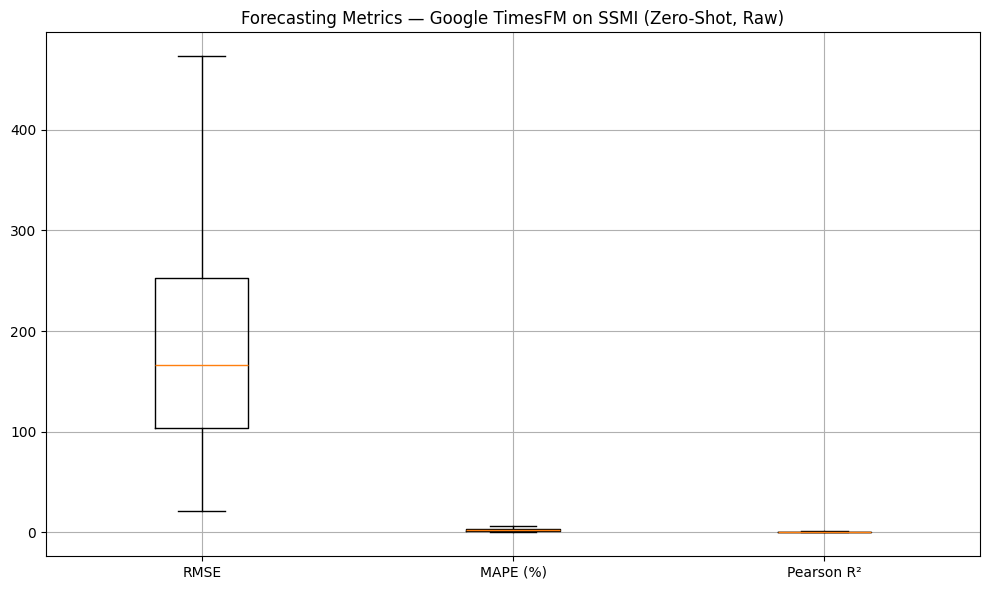

In [1]:
import numpy as np
import pandas as pd
import timesfm
import matplotlib.pyplot as plt
import logging
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from scipy.stats import pearsonr

logging.basicConfig(
    filename='TimesFM_SSMI_Metrics.log',
    level=logging.INFO,
    format='%(asctime)s %(levelname)s: %(message)s',
    force=True
)

def main():
    try:
        # ========================
        # 1) Load SSMI data
        # ========================
        df = pd.read_csv("../DataSets/SSMI cleaned/SSMI_cleaned.csv", parse_dates=["Date"])
        df = df.sort_values("Date").reset_index(drop=True)

        y = df["Adj Close"].values.astype(float)
        total_samples = len(y)
        logging.info(f"Total SSMI samples loaded: {total_samples}")

        # ========================
        # 2) Sliding window config
        # ========================
        context_window   = 120
        forecast_horizon = 30
        step_size        = 30
        num_segments     = (total_samples - context_window) // step_size
        logging.info(f"Segments to evaluate: {num_segments}")

        # ========================
        # 3) Load TimesFM
        # ========================
        tfm = timesfm.TimesFm(
            hparams=timesfm.TimesFmHparams(
                backend="cpu",
                per_core_batch_size=32,
                horizon_len=forecast_horizon,
            ),
            checkpoint=timesfm.TimesFmCheckpoint(
                huggingface_repo_id="google/timesfm-1.0-200m-pytorch",
            ),
        )
        logging.info("Google TimesFM loaded successfully.")

        # ========================
        # 4) Sliding window loop (raw, no filter)
        # ========================
        rmse_list        = []
        mape_list        = []
        pearson_list     = []
        directional_hits = []

        for segment in range(num_segments):
            start_context = segment * step_size
            end_context   = start_context + context_window
            if end_context + forecast_horizon > total_samples:
                break

            context_raw   = y[start_context:end_context].copy()
            true_combined = y[end_context:end_context + forecast_horizon]

            # Single forecast on raw context
            point_forecast, _ = tfm.forecast(
                [context_raw],
                freq=[0],
            )
            combined_pred = point_forecast[0][:forecast_horizon]

            # ========================
            # Directional accuracy
            # (correct up AND correct down)
            # ========================
            prev_day_price = y[end_context - 1]

            actual_prev = np.concatenate([[prev_day_price], true_combined[:-1]])
            pred_prev   = np.concatenate([[prev_day_price], combined_pred[:-1]])

            actual_direction = np.sign(true_combined - actual_prev)
            pred_direction   = np.sign(combined_pred  - pred_prev)

            hits = (actual_direction == pred_direction).astype(int)
            directional_hits.extend(hits.tolist())

            # Standard metrics
            rmse = np.sqrt(mean_squared_error(true_combined, combined_pred))
            mape = mean_absolute_percentage_error(true_combined, combined_pred) * 100
            r2 = pearsonr(true_combined, combined_pred).statistic ** 2

            rmse_list.append(rmse)
            mape_list.append(mape)
            pearson_list.append(r2)

            segment_dir_acc = hits.mean() * 100
            logging.info(f"Segment {segment+1}/{num_segments}: RMSE={rmse:.4f}, MAPE={mape:.4f}%, R\u00b2={r2:.4f}, DirAcc={segment_dir_acc:.1f}%")
            print(f"Segment {segment+1}/{num_segments} \u2014 RMSE: {rmse:.2f} | MAPE: {mape:.2f}% | R\u00b2: {r2:.4f} | Dir Acc: {segment_dir_acc:.1f}%")

        # ========================
        # 5) Save results
        # ========================
        np.savez_compressed("TimesFM_SSMI_Metrics.npz",
                            rmse=np.array(rmse_list),
                            mape=np.array(mape_list),
                            pearson_coefficients=np.array(pearson_list),
                            directional_hits=np.array(directional_hits),
                            context_window=context_window,
                            forecast_horizon=forecast_horizon,
                            num_segments=num_segments)
        logging.info("Results saved to TimesFM_SSMI_Metrics.npz")

        # ========================
        # 6) Summary metrics
        # ========================
        total_days  = len(directional_hits)
        total_hits  = sum(directional_hits)
        dir_acc_pct = (total_hits / total_days) * 100

        print("\n--- Median Metrics for Google TimesFM on SSMI (Zero-Shot, Raw) ---")
        print(f"Median RMSE:          {np.median(rmse_list):.4f}")
        print(f"Median MAPE:          {np.median(mape_list):.4f}%")
        print(f"Median Pearson R\u00b2:    {np.median(pearson_list):.4f}")
        print(f"Directional Accuracy: {total_hits}/{total_days} days ({dir_acc_pct:.2f}%)")

        # ========================
        # 7) Box plots
        # ========================
        metrics = {
            "RMSE":     rmse_list,
            "MAPE (%)":  mape_list,
            "Pearson R\u00b2": pearson_list,
        }

        plt.figure(figsize=(10, 6))
        plt.boxplot(metrics.values(), labels=metrics.keys(), showfliers=False)
        plt.title("Forecasting Metrics \u2014 Google TimesFM on SSMI (Zero-Shot, Raw)")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        logging.error("An error occurred.", exc_info=True)
        print("An error occurred. Check TimesFM_SSMI_Metrics.log for details.")
        try:
            np.savez_compressed("partial_TimesFM_SSMI_Metrics.npz",
                                rmse=np.array(rmse_list) if 'rmse_list' in locals() else None,
                                mape=np.array(mape_list) if 'mape_list' in locals() else None,
                                pearson_coefficients=np.array(pearson_list) if 'pearson_list' in locals() else None,
                                directional_hits=np.array(directional_hits) if 'directional_hits' in locals() else None)
        except Exception as save_exception:
            logging.error("Failed to save partial results.", exc_info=True)
    finally:
        logging.info("Forecasting run completed.")

if __name__ == '__main__':
    main()
